## Step 1: Load data and rebuild focal_term → PMID mapping

In [9]:
import pandas as pd

# Raw sources
df_pat  = pd.read_parquet('../data/raw/SampleGloria_Pat_GlinerLabels.parquet')   # patent_id, term
df_pmed = pd.read_parquet('../data/raw/SampleGloria_Pmed_GlinerLabels.parquet')  # pmid (int), term
df_link = pd.read_parquet('../data/raw/SampleGloria_Link_PmidOa.parquet')        # patent_id, pmid (URL)

# Pre-computed focal terms (aggregated)
df_focal = pd.read_parquet('../output/focal_terms.parquet')     # patent_id, focal_term

print('Pat rows:  ', len(df_pat))
print('Pmed rows: ', len(df_pmed))
print('Link rows: ', len(df_link))
print('Focal rows:', len(df_focal))

Pat rows:   23312
Pmed rows:  31831
Link rows:  6104
Focal rows: 790


In [10]:
# Clean link table: extract numeric pmid from URL, drop rows without pmid
df_link_clean = df_link.dropna(subset=['pmid']).copy()
df_link_clean['pmid'] = df_link_clean['pmid'].str.extract(r'(\d+)$').astype('int32')
df_link_clean = df_link_clean[['patent_id', 'pmid']].drop_duplicates()
print('patent-pmid pairs:', len(df_link_clean))

patent-pmid pairs: 3997


In [11]:
# Merge pmed terms with patent_id via the link table
cited_terms = df_pmed[['pmid', 'term']].merge(df_link_clean, on='pmid', how='inner')

# Rebuild focal_terms_with_pmid:
#   A (patent_id, term) is a focal term if it appears in both
#   the patent AND in at least one cited paper of that patent.
patent_term_set = df_pat[['patent_id', 'term']].drop_duplicates()
focal_with_pmid = patent_term_set.merge(
    cited_terms[['patent_id', 'pmid', 'term']].drop_duplicates(),
    on=['patent_id', 'term'],
    how='inner'
).rename(columns={'term': 'focal_term'})

print('focal_with_pmid shape:', focal_with_pmid.shape)
focal_with_pmid.head()

focal_with_pmid shape: (1743, 3)


,patent_id,focal_term,pmid
0,7662783,effective,17483349
1,7662783,antagonist,11387236
2,7662783,collagen,11387236
3,7662783,collagen,11535623
4,7662783,collagen,17110907


## Step 2: Build patent context per (patent_id, focal_term)

Patent context = **set of all terms in the patent** minus the focal term itself.

In [12]:
# Unique terms per patent (as a dict: patent_id -> frozenset of terms)
patent_term_sets = (
    df_pat.groupby('patent_id')['term']
          .apply(set)
          .to_dict()
)
print('Patents with term sets:', len(patent_term_sets))

Patents with term sets: 252


## Step 3: Build paper context per (patent_id, focal_term)

Paper context = **set of all terms** in the PMIDs where the focal term appears (for that patent) minus the focal term.

In [13]:
# For each (patent_id, focal_term) → set of relevant PMIDs
focal_pmids = (
    focal_with_pmid.groupby(['patent_id', 'focal_term'])['pmid']
                   .apply(set)
                   .reset_index(name='pmid_set')
)

# Build a dict: pmid -> set of terms (from pmed)
pmid_term_sets = (
    df_pmed.groupby('pmid')['term']
           .apply(set)
           .to_dict()
)
print('PMIDs with term sets:', len(pmid_term_sets))

PMIDs with term sets: 706


In [14]:
def paper_context(pmid_set, focal_term):
    """Union of terms across the relevant PMIDs, minus the focal term."""
    terms = set()
    for pmid in pmid_set:
        terms |= pmid_term_sets.get(pmid, set())
    terms.discard(focal_term)
    return terms

focal_pmids['paper_ctx'] = focal_pmids.apply(
    lambda r: paper_context(r['pmid_set'], r['focal_term']), axis=1
)
focal_pmids.head(3)

,patent_id,focal_term,pmid_set,paper_ctx
0,7662783,alpha,{11387236},"{bind, binding, αvβ3, differentiate, matrix, s..."
1,7662783,antagonist,{11387236},"{bind, binding, αvβ3, differentiate, matrix, s..."
2,7662783,cell,"{12746434, 11535623, 12071856, 12454288, 17483...","{umbilical, vein, bound, binding, use, angioge..."


In [15]:
rows = []
for _, row in focal_pmids.iterrows():
    pid   = row['patent_id']
    ft    = row['focal_term']
    
    # Patent context: all patent terms minus the focal term
    pat_ctx = patent_term_sets.get(pid, set()) - {ft}
    
    # Paper context already computed
    pap_ctx = row['paper_ctx']
    
    
    rows.append({
        'patent_id':          pid,
        'focal_term':         ft,
        'pmids':              row['pmid_set'],
        'patent_context':     pat_ctx,
        'paper_context':      pap_ctx
    })

focal_term_contexts = pd.DataFrame(rows)
focal_term_contexts.to_parquet("../output/focal_term_context.parquet")
focal_term_contexts.head()


,patent_id,focal_term,pmids,patent_context,paper_context
0,7662783,alpha,{11387236},"{cervix, tumors, gy, proton, administered, pha...","{bind, binding, αvβ3, differentiate, matrix, s..."
1,7662783,antagonist,{11387236},"{cervix, tumors, gy, proton, administered, pha...","{bind, binding, αvβ3, differentiate, matrix, s..."
2,7662783,cell,"{12746434, 11535623, 12071856, 12454288, 17483...","{cervix, tumors, gy, proton, administered, pha...","{umbilical, vein, bound, binding, use, angioge..."
3,7662783,collagen,"{17110907, 11387236, 11535623}","{cervix, tumors, gy, proton, administered, pha...","{binding, differentiate, angiogenesis, membran..."
4,7662783,colon,{12746434},"{cervix, tumors, gy, proton, administered, pha...","{abrogate, umbilical, chorioallantoic, resulta..."


In [24]:
patent_sentences = [f"{row['focal_term']} {' '.join(row['patent_context'])}" for _, row in focal_term_contexts.iterrows()]
patent_sentences                               

['alpha cervix tumors gy proton administered pharynx kidney combination liver gamma about treatment solid tumor glioblastoma breast radiation solid beta collagen effective sequence neutron particles comprises therapy ovary sensitivity colon electrons neutrons antagonist melanoma amino acid sequence least neuroblastoma sarcoma electron sweat gland at lung cell administering proliferation marrow negative pi mesons x-rays bladder increases effect treating patient colorectal larynx pancreas neck intestine radiation therapy joint kaposi comprising head amount bone testicle lymph node tumor stomach amino acid synergistic method total growth skin beams uterus prostate peptide endometrius',
 'antagonist cervix tumors gy proton administered pharynx kidney combination liver gamma about treatment solid tumor glioblastoma breast radiation solid beta collagen effective sequence neutron particles comprises therapy ovary sensitivity colon electrons neutrons melanoma amino acid sequence least neurobla

In [17]:
paper_sentences = [f"{row['focal_term']} {' '.join(row['paper_context'])}" for _, row in focal_term_contexts.iterrows()]
paper_sentences  

['alpha bind binding αvβ3 differentiate matrix site likely surface chain functional role chromatography block ubiquitous beta3 metastasis important receptor capillary-like fibronectin and phosphorylation collagen laminin adhesion gamma1 healing screening α5β1 vivo tumor angiogenic alpha5beta1 attachment growth wound potent therapeutic activity antagonist laminin-1 peptide',
 'antagonist bind binding αvβ3 differentiate matrix site likely surface chain functional role chromatography block ubiquitous beta3 metastasis important receptor capillary-like fibronectin and phosphorylation collagen laminin adhesion gamma1 healing screening α5β1 vivo tumor angiogenic alpha alpha5beta1 attachment growth wound potent therapeutic activity laminin-1 peptide',
 'cell umbilical vein bound binding use angiogenesis high anti-angiogenic apo chick protease-like epitope role within subunit poor alpha1beta1 close evolution proteolysis factor regulate inhibitor synthetic proteolytic responsible mutagenesis fir

In [18]:
from sentence_transformers import SentenceTransformer
#sentences = ["This is an example sentence", "Each sentence is converted"]

#model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
#embeddings = model.encode(sentences)
 #print(embeddings)


/Users/gloria/Library/Caches/pypoetry/virtualenvs/hiwi-02P-lfTy-py3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [19]:
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# Encode both lists — index i of patent_embeddings corresponds to index i of paper_embeddings
patent_embeddings = model.encode(patent_sentences, show_progress_bar=True)
paper_embeddings  = model.encode(paper_sentences,  show_progress_bar=True)

print("patent_embeddings shape:", patent_embeddings.shape)
print("paper_embeddings shape: ", paper_embeddings.shape)

# Quick sanity check: first pair
print("\nFirst patent sentence:", patent_sentences[0][:80], "...")
print("First paper sentence: ", paper_sentences[0][:80], "...")
print("patent_embeddings[0]:", patent_embeddings[0][:5], "...")
print("paper_embeddings[0]: ", paper_embeddings[0][:5], "...")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6670.17it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 25/25 [00:04<00:00,  6.12it/s]

patent_embeddings shape: (790, 384)
paper_embeddings shape:  (790, 384)

First patent sentence: alpha cervix tumors gy proton administered pharynx kidney combination liver gamm ...
First paper sentence:  alpha bind binding αvβ3 differentiate matrix site likely surface chain functiona ...
patent_embeddings[0]: [-0.03715242 -0.03163405 -0.00446788 -0.02420976 -0.05168387] ...
paper_embeddings[0]:  [-0.06130734 -0.10325238 -0.07597724 -0.03585204  0.05577875] ...


In [20]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Cosine similarity between each patent/paper embedding pair (row-wise)
similarities = cosine_similarity(patent_embeddings, paper_embeddings).diagonal()

focal_term_contexts['cosine_similarity'] = similarities

print(focal_term_contexts[['patent_id', 'focal_term', 'cosine_similarity']].head(50))
focal_term_contexts.to_parquet("../output/cosine_similarity_results.parquet")

   patent_id       focal_term  cosine_similarity
0    7662783            alpha           0.388263
1    7662783       antagonist           0.388860
2    7662783             cell           0.261124
3    7662783         collagen           0.324649
4    7662783            colon           0.329872
5    7662783           effect           0.202818
6    7662783        effective           0.312419
7    7662783           growth           0.374723
8    7662783             lung           0.329380
9    7662783         melanoma           0.370967
10   7662783          peptide           0.385727
11   7662783    proliferation           0.400150
12   7662783         sequence           0.179552
13   7662783             skin           0.331590
14   7662783        treatment           0.311062
15   7662783            tumor           0.322257
16   7700783            agent           0.148407
17   7700783         hydroxyl           0.258152
18   7704363              and           0.264853
19   7704363    conc

Cosine Similarity Statistics
  Mean:   0.425
  Median: 0.419
  Std:    0.141
  Min:    -0.008
  Max:    0.847


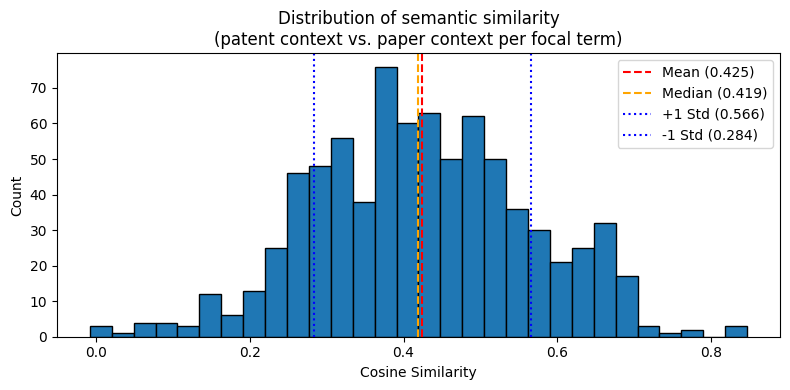

In [21]:
import matplotlib.pyplot as plt

sim = focal_term_contexts['cosine_similarity']

# --- Quantitative summary ---
print("Cosine Similarity Statistics")
print(f"  Mean:   {sim.mean():.3f}")
print(f"  Median: {sim.median():.3f}")
print(f"  Std:    {sim.std():.3f}")
print(f"  Min:    {sim.min():.3f}")
print(f"  Max:    {sim.max():.3f}")

# --- Histogram ---
plt.figure(figsize=(8, 4))
plt.hist(sim, bins=30, edgecolor='black')
plt.axvline(sim.mean(),              color='red',    linestyle='--', label=f'Mean ({sim.mean():.3f})')
plt.axvline(sim.median(),            color='orange', linestyle='--', label=f'Median ({sim.median():.3f})')
plt.axvline(sim.mean() + sim.std(),  color='blue',   linestyle=':',  label=f'+1 Std ({sim.mean()+sim.std():.3f})')
plt.axvline(sim.mean() - sim.std(),  color='blue',   linestyle=':',  label=f'-1 Std ({sim.mean()-sim.std():.3f})')
plt.xlabel('Cosine Similarity')
plt.ylabel('Count')
plt.title('Distribution of semantic similarity\n(patent context vs. paper context per focal term)')
plt.legend()
plt.tight_layout()
plt.savefig("../visualizations/cosine_similarity_distribution.png", dpi=150)
plt.show()

In [22]:
n = 5  # number of examples to show

top = focal_term_contexts.nlargest(n, 'cosine_similarity')[['patent_id', 'focal_term', 'patent_context', 'paper_context', 'cosine_similarity']]
bot = focal_term_contexts.nsmallest(n, 'cosine_similarity')[['patent_id', 'focal_term', 'patent_context', 'paper_context', 'cosine_similarity']]

print("=== HIGH similarity (focal term used in similar contexts) ===")
for _, row in top.iterrows():
    print(f"\nFocal term: '{row['focal_term']}'  (patent_id={row['patent_id']},  sim={row['cosine_similarity']:.3f})")
    print(f"  Patent ctx (sample): {', '.join(list(row['patent_context'])[:10])}")
    print(f"  Paper  ctx (sample): {', '.join(list(row['paper_context'])[:10])}")

print("\n=== LOW similarity (focal term used in different contexts) ===")
for _, row in bot.iterrows():
    print(f"\nFocal term: '{row['focal_term']}'  (patent_id={row['patent_id']},  sim={row['cosine_similarity']:.3f})")
    print(f"  Patent ctx (sample): {', '.join(list(row['patent_context'])[:10])}")
    print(f"  Paper  ctx (sample): {', '.join(list(row['paper_context'])[:10])}")

=== HIGH similarity (focal term used in similar contexts) ===

Focal term: 'asbestos-related'  (patent_id=8168398,  sim=0.847)
  Patent ctx (sample): biological, concentration, exposed, indicates, in, predetermined, having, lung, assessing, increased
  Paper  ctx (sample): curve, without, nonmalignant, respectively, distinguish, than, serum, osteopontin, analysis, presence

Focal term: 'presence'  (patent_id=8168398,  sim=0.834)
  Patent ctx (sample): biological, concentration, exposed, indicates, in, predetermined, having, lung, assessing, increased
  Paper  ctx (sample): curve, without, nonmalignant, respectively, distinguish, than, serum, osteopontin, analysis, value

Focal term: 'asbestos'  (patent_id=8168398,  sim=0.827)
  Patent ctx (sample): biological, concentration, exposed, indicates, in, predetermined, having, lung, assessing, increased
  Paper  ctx (sample): many, curve, upward, radiographic, use, nonmalignant, finding, high, parenchyma, large

Focal term: 'cocaine'  (paten